In [16]:
import pandas as pd
import  numpy as np

# read -> Ler
# dataframe -> Base de dados do Panda = df

df_vendas = pd.read_csv("vendas_tech.csv", low_memory=False) # encoding="latin1" --- sep=","
display(df_vendas)
df_gerente = pd.read_excel("gerentes_lojas.xlsx")
display(df_gerente)

,ID_Pedido,Data,Loja,Produto,Preco_Unitario,Qtd,Cliente,Data_Base
0,1,2023-06-08,São Paulo,Mouse Gamer,120.0,1,Cliente_4095,2025-01-01
1,2,2023-03-01,Belo Horizonte,iPhone 14,5500.0,1,Cliente_8750,NaN
2,3,2023-02-25,NaN,"Monitor 27""",1200.0,1,Cliente_14859,NaN
3,4,2024-11-19,RIO DE JANEIRO,Mouse Gamer,120.0,2,Cliente_17343,NaN
4,5,2024-01-27,Rio de Janeiro,Smartphone Samsung,2200.0,1,Cliente_23377,NaN
...,...,...,...,...,...,...,...,...
100095,94091,2023-10-20,Porto Alegre,iPhone 14,5500.0,1,Cliente_11755,NaN
100096,52883,2024-03-17,Porto Alegre,Notebook Dell,3500.0,2,Cliente_12879,NaN
100097,65070,2023-06-19,Belo Horizonte,Smartphone Samsung,2200.0,2,Cliente_8160,NaN
100098,94031,2024-06-14,Salvador,iPhone 14,5500.0,2,Cliente_28545,NaN


,Loja,Gerente,Meta_Mensal
0,São Paulo,Carlos,50000
1,Rio de Janeiro,Fernanda,60000
2,Curitiba,Roberto,45000
3,Belo Horizonte,Juliana,55000
4,Recife,Marcos,48000
5,Porto Alegre,Pedro,42000
6,Salvador,Ana,52000


In [35]:
# INSPEÇÃO
#display(df_vendas.head(10)) # head -> AS PRIMEIRAS LINHAS
#display(df_vendas.tail(10)) # tail -> AS ULTIMAS LINHAS
#display(df_vendas.sample(10)) # sample -> LINHAS ALEATORIAS

display(df_vendas.shape) # shape -> Para mostrar a quantidade de linhas e colunas

display(list(df_vendas.columns)) # Mostrar o nome das colunas

(100100, 8)

['ID_Pedido',
 'Data',
 'Loja',
 'Produto',
 'Preco_Unitario',
 'Qtd',
 'Cliente',
 'Data_Base']

In [18]:
display(df_vendas.info())
display(df_vendas.describe())

<class 'pandas.DataFrame'>
RangeIndex: 100100 entries, 0 to 100099
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   ID_Pedido       100100 non-null  int64  
 1   Data            100100 non-null  str    
 2   Loja            98099 non-null   str    
 3   Produto         100100 non-null  str    
 4   Preco_Unitario  100100 non-null  float64
 5   Qtd             100100 non-null  int64  
 6   Cliente         100100 non-null  str    
 7   Data_Base       1 non-null       str    
dtypes: float64(1), int64(2), str(5)
memory usage: 6.1 MB


None

,ID_Pedido,Preco_Unitario,Qtd
count,100100.000000,100100.000000,100100.000000
mean,50004.810180,2000.204595,1.499101
std,28866.872543,1841.050733,1.241605
min,1.000000,40.000000,1.000000
25%,25008.750000,120.000000,1.000000
50%,50004.500000,1200.000000,1.000000
75%,75002.250000,3200.000000,1.000000
max,100000.000000,5500.000000,10.000000


In [34]:
# TRATAMENRO DE DADOS
df_vendas["Loja"] # selecionando coluna

# colunas
df_analise = df_vendas.drop(columns=["Data_Base"]) # EXCLUIR LINHAS OU COLUNAS
#display(df_analise)

# nulos
df_analise = df_analise.dropna() # EXCLUI VALORES VAZIOS
#display(df_analise)

# tipos de dados
df_analise["Data"] = pd.to_datetime(df_analise["Data"], format="%Y-%m-%d")

# padronização
df_analise["Loja"] = df_analise["Loja"].str.strip() # Tirar os espaços
df_analise["Loja"] = df_analise["Loja"].str.title() # Padronizar os nomes

df_gerente["Loja"] = df_gerente["Loja"].str.strip() # Tirar os espaços
df_gerente["Loja"] = df_gerente["Loja"].str.title() # Padronizar os nomes

# duplicatas
df_analise = df_analise.drop_duplicates(subset=["ID_Pedido"])




#display(df_analise)
display(df_vendas.info())

<class 'pandas.DataFrame'>
RangeIndex: 100100 entries, 0 to 100099
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   ID_Pedido       100100 non-null  int64  
 1   Data            100100 non-null  str    
 2   Loja            98099 non-null   str    
 3   Produto         100100 non-null  str    
 4   Preco_Unitario  100100 non-null  float64
 5   Qtd             100100 non-null  int64  
 6   Cliente         100100 non-null  str    
 7   Data_Base       1 non-null       str    
dtypes: float64(1), int64(2), str(5)
memory usage: 6.1 MB


None

In [33]:
# CRIAR NOVAS COLUNAS

# FATURAMENTO
df_analise["Faturamento"] = df_analise["Qtd"] * df_analise["Preco_Unitario"]

# FORMA DE VENDA
df_analise["Forma_de_Venda"] = np.where(df_analise["Loja"]=="Online", "Online", "Presencial") # np = if -> Analisar uma coluna e tratalar

# REGIAO
#display(df_analise["Loja"].unique()) # Visualizar uma unica coluna

dic_regioes = {
    'São Paulo': "Sudeste",
    'Belo Horizonte': "Sudeste",
    'Online': "Online",
    'Rio De Janeiro': "Sudeste",
    'Salvador': "Nordeste",
    'Recife': "Nordeste",
    'Curitiba': "Sul",
    'Porto Alegre': "Sul"
    }

df_analise["Regiao"] = df_analise["Loja"].map(dic_regioes)



#display(df_analise)
display(df_analise.isna().sum())

ID_Pedido         0
Data              0
Loja              0
Produto           0
Preco_Unitario    0
Qtd               0
Cliente           0
Faturamento       0
Forma_de_Venda    0
Regiao            0
Mes-ano           0
Mes-Ano           0
dtype: int64

In [32]:
# ANALISAR -> filtrar

df_analise = df_analise.sort_values(by=["Data", "Faturamento"], ascending=True) # Ordenando do mais antigo para o mais novo
df_analise = df_analise.reset_index(drop=True) # drop=True --> jogar o index antigo para fora

# .loc -> id do pedido --> por nome da coluna e por nome da linha
id_pedido = 4

loja = df_analise.loc[3, "Loja"]
produto = df_analise.loc[3, "Produto"]
cliente = df_analise.loc[3, "Cliente"]
print(loja, produto, cliente)

# comdicional
df_id_pedido_4 = df_analise[df_analise["ID_Pedido"]==4]

# exportar pedaços da base
df_vendas_sp = df_analise[df_analise["Loja"]=="São Paulo"]
df_vendas_sp.to_csv("Vendas_SP.csv", index=False) # TRANSFORMAR ESSA TABELA EM UM ARQUIVO CSV

# exportar as vendas de 2024
df_vendas_2024 = df_analise[df_analise["Data"].dt.year==2024]

# duplas condições
df_vendas_HDMI_SUL = df_analise[(df_analise["Produto"]=="Cabo HDMI") & (df_analise["Regiao"]=="Sul")]

#display(df_analise)
#display(df_id_pedido_4)
#display(df_vendas_sp)
#display(df_vendas_2024)
#display(df_vendas_HDMI_SUL)

Porto Alegre Cabo HDMI Cliente_22886


In [22]:
# ANALISE POR AGRUPAMENTO
#display(df_analise)

# ranking de faturamento por loja
analise_lojas = df_analise[["Loja", "Faturamento"]].groupby("Loja").sum()
analise_lojas = analise_lojas.sort_values(by="Faturamento", ascending=True)
analise_lojas["Faturamento"] = analise_lojas["Faturamento"].map("R${:,.2f}".format) # CODIGO DE FORMATAÇÃO
display(analise_lojas)

# ranking de produtos que mais venderam no online
df_vendas_online = df_analise[df_analise["Loja"]=="Online"]

#analise de rankind por loja e por peoduto
# quais produtos venderam mais em cada loja
analise_produtos_em_lojas = df_analise[["Loja", "Produto", "Qtd"]].groupby(["Loja", "Produto"]).sum()

# quais lojas mais venderam os produtos
analise_lojas_em_produtos = df_analise[["Loja", "Produto", "Qtd"]].groupby(["Produto", "Loja"]).sum()

#display(analise_lojas_em_produtos)

,Faturamento
Loja,
Curitiba,"R$41,121,720.00"
Porto Alegre,"R$41,678,460.00"
Belo Horizonte,"R$41,714,890.00"
São Paulo,"R$42,090,690.00"
Recife,"R$42,190,390.00"
Rio De Janeiro,"R$42,294,720.00"
Salvador,"R$42,300,610.00"


In [25]:
# quais gerentes bateram a meta em janeiro de 2023
df_vendas_gerentes_janeiro_23 = df_analise[(df_analise["Data"].dt.year==2023) & (df_analise["Data"].dt.month==1)]

df_vendas_gerentes_janeiro_23 = df_vendas_gerentes_janeiro_23[["Loja", "Faturamento"]].groupby("Loja", as_index=False).sum()

df_vendas_gerentes_janeiro_23 = df_vendas_gerentes_janeiro_23.merge(df_gerente, on="Loja", how="left") # juntar duas tabelas

df_vendas_gerentes_janeiro_23["Bateu a Meta"] = np.where(df_vendas_gerentes_janeiro_23["Faturamento"] >= df_vendas_gerentes_janeiro_23["Meta_Mensal"], "Sim", "Não")

display(df_vendas_gerentes_janeiro_23)

,Loja,Faturamento,Gerente,Meta_Mensal,Bateu a Meta
0,Belo Horizonte,1779100.0,Juliana,55000,Sim
1,Curitiba,1986920.0,Roberto,45000,Sim
2,Porto Alegre,1726640.0,Pedro,42000,Sim
3,Recife,1779020.0,Marcos,48000,Sim
4,Rio De Janeiro,1736830.0,Fernanda,60000,Sim
5,Salvador,1686070.0,Ana,52000,Sim
6,São Paulo,1831140.0,Carlos,50000,Sim


,Faturamento
Mes-Ano,
2023-01,12525720.0
2023-02,11302480.0
2023-03,12296790.0
2023-04,12294830.0
2023-05,12676320.0
2023-06,12153610.0
2023-07,12279750.0
2023-08,12780520.0
2023-09,11852240.0


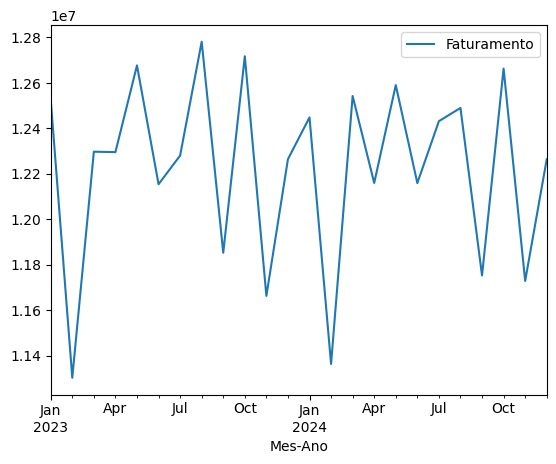

In [31]:
df_analise["Mes-Ano"] = df_analise["Data"].dt.to_period("M")
df_vendas_mes = df_analise[["Mes-Ano", "Faturamento"]].groupby("Mes-Ano").sum()
df_vendas_mes.plot()

display(df_vendas_mes)